In [16]:
# ==========================================
# Step 1 & 2: Setup, Assumptions & Load Data
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("--- Initializing Global Config & Assumptions ---")

# 1. Portability: Relative File Paths (Assumes data is in the same folder as the notebook)
DATA_DIR = "./"

# 2. Explicit Simulation Assumptions (Clearly defined for transparency)
ASSUMPTIONS = {
    "charger_power_kw": 7.4,      # Standard AC charger power draw
    "baseline_tariff": 15.0,      # Current flat rate (₹/kWh)
    "surge_multiplier": 1.30,     # +30% price during >80% utilization
    "discount_multiplier": 0.80,  # -20% price during <30% utilization
    "elasticity_surge": -0.15,    # A 30% price hike reduces demand by 15%
    "elasticity_discount": 0.25   # A 20% price drop increases demand by 25%
}

print(f"Data Directory set to: '{DATA_DIR}'")
print("Simulation Assumptions Loaded.")

# 3. Load Datasets Using Portable Paths
print("\nLoading ACN-Data...")
try:
    acn_path = os.path.join(DATA_DIR, 'acndata_sessions.json.xlsx - Sheet1.csv')
    acn_df = pd.read_csv(acn_path)
except Exception as e:
    # Fallback to pure excel format if the csv export isn't found
    try:
        acn_df = pd.read_excel(os.path.join(DATA_DIR, 'acndata_sessions.json.xlsx'))
    except Exception as ex:
        print(f"Error loading ACN-Data: {ex}")

print("Loading UrbanEV Datasets...")
urban_ev_paths = {
    'adj': 'adj.csv', 'distance': 'distance.csv', 'duration': 'duration.csv',
    'information': 'information.csv', 'occupancy': 'occupancy.csv',
    'price': 'price.csv', 'stations': 'stations.csv', 'time': 'time.csv'
}

urban_ev_dfs = {}
for name, file_name in urban_ev_paths.items():
    try:
        urban_ev_dfs[name] = pd.read_csv(os.path.join(DATA_DIR, file_name))
    except Exception as e:
        print(f"Error loading UrbanEV - {name}: {e}")

print("Data loading complete.")

--- Initializing Global Config & Assumptions ---
Data Directory set to: './'
Simulation Assumptions Loaded.

Loading ACN-Data...
Error loading ACN-Data: [Errno 2] No such file or directory: './acndata_sessions.json.xlsx'
Loading UrbanEV Datasets...
Error loading UrbanEV - adj: [Errno 2] No such file or directory: './adj.csv'
Error loading UrbanEV - distance: [Errno 2] No such file or directory: './distance.csv'
Error loading UrbanEV - duration: [Errno 2] No such file or directory: './duration.csv'
Error loading UrbanEV - information: [Errno 2] No such file or directory: './information.csv'
Error loading UrbanEV - occupancy: [Errno 2] No such file or directory: './occupancy.csv'
Error loading UrbanEV - price: [Errno 2] No such file or directory: './price.csv'
Error loading UrbanEV - stations: [Errno 2] No such file or directory: './stations.csv'
Error loading UrbanEV - time: [Errno 2] No such file or directory: './time.csv'
Data loading complete.


Step 3: Understand the Schema

In [17]:
def analyze_schema(df, dataset_name):
    print(f"\n{'='*70}")
    print(f"SCHEMA ANALYSIS: {dataset_name.upper()}")
    print(f"{'='*70}")

    # 1. What is one row?
    print(f"1. WHAT IS ONE ROW?")
    print(f"   Total records: {len(df)}")
    print("   Look at this sample row to determine if it's a single session, a 5-min interval, or a station profile:")
    display(df.head(1))

    # Heuristics to find specific columns
    cols = df.columns

    # 2. Timestamp column
    time_cols = [c for c in cols if any(kw in str(c).lower() for kw in ['time', 'date', 'start', 'end', 'timestamp', 'period'])]
    print(f"\n2. POTENTIAL TIMESTAMP COLUMN(S):")
    print(f"   Found: {time_cols}")

    # 3. Station / Pile identifier
    id_cols = [c for c in cols if any(kw in str(c).lower() for kw in ['id', 'station', 'pile', 'site', 'name', 'node'])]
    print(f"\n3. POTENTIAL STATION / PILE IDENTIFIER(S):")
    print(f"   Found: {id_cols}")

    # 4. Energy / Session Duration
    energy_cols = [c for c in cols if any(kw in str(c).lower() for kw in ['energy', 'kwh', 'power', 'duration', 'charge', 'delivered'])]
    print(f"\n4. POTENTIAL ENERGY / DURATION COLUMN(S):")
    print(f"   Found: {energy_cols}")

    # 5. Demand or Utilization proxy
    demand_cols = [c for c in cols if any(kw in str(c).lower() for kw in ['occupancy', 'volume', 'status', 'utilization', 'demand', 'price', 'cost', 'adj'])]
    print(f"\n5. POTENTIAL DEMAND / UTILIZATION PROXY:")
    print(f"   Found: {demand_cols}")
    print("-" * 70)

# Analyze ACN Data
if 'acn_df' in locals() and acn_df is not None:
    analyze_schema(acn_df, "ACN-Data Sessions")
else:
    print("acn_df not found. Did Step 2 run successfully?")

# Analyze key UrbanEV Datasets
# We focus on the files most likely to contain session/demand data based on their names
if 'urban_ev_dfs' in locals():
    key_urban_files = ['information', 'time', 'volume', 'occupancy', 'duration']
    for name in key_urban_files:
        if name in urban_ev_dfs:
            analyze_schema(urban_ev_dfs[name], f"UrbanEV: {name}")
else:
    print("urban_ev_dfs not found. Did Step 2 run successfully?")

print("\n[ACTION REQUIRED]: Review the printed lists above to write down the exact column names you will use for alignment.")


SCHEMA ANALYSIS: ACN-DATA SESSIONS
1. WHAT IS ONE ROW?
   Total records: 16304
   Look at this sample row to determine if it's a single session, a 5-min interval, or a station profile:


,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,...,userID,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39.0,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



2. POTENTIAL TIMESTAMP COLUMN(S):
   Found: ['end', 'start', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'timezone']

3. POTENTIAL STATION / PILE IDENTIFIER(S):
   Found: ['site', '_id', 'clusterID', 'sessionID', 'siteID', 'spaceID', 'stationID', 'userID', 'userID.1']

4. POTENTIAL ENERGY / DURATION COLUMN(S):
   Found: ['min_kWh', 'kWhDelivered', 'kWhRequested']

5. POTENTIAL DEMAND / UTILIZATION PROXY:
   Found: []
----------------------------------------------------------------------

[ACTION REQUIRED]: Review the printed lists above to write down the exact column names you will use for alignment.


Step 4: Clean and Standardize

In [18]:
# Initialize transparency log as required by the project brief
assumption_log = []

def log_assumption(step_name, description):
    log_entry = f"[{step_name}] {description}"
    assumption_log.append(log_entry)
    print(log_entry)

print("--- Starting Cleaning Pipeline ---\n")

# ------------------------------------------
# 1. Cleaning ACN-Data
# ------------------------------------------
if 'acn_df' in locals() and acn_df is not None:
    print("Processing ACN-Data...")

    # Assumption: Drop rows that are entirely empty or missing critical identifiers due to export shifting
    initial_shape = acn_df.shape
    acn_cleaned = acn_df.dropna(subset=['sessionID', 'stationID', 'connectionTime'])
    log_assumption("ACN_Drop_Missing", f"Dropped rows missing key IDs. Rows reduced from {initial_shape[0]} to {acn_cleaned.shape[0]}.")

    # Standardize column names to lower_snake_case
    acn_cleaned.columns = acn_cleaned.columns.str.strip().str.lower()

    # Parse datetime columns (handling GMT/UTC strings safely)
    datetime_cols = ['connectiontime', 'disconnecttime', 'donechargingtime']
    for col in datetime_cols:
        if col in acn_cleaned.columns:
            acn_cleaned[col] = pd.to_datetime(acn_cleaned[col], errors='coerce')
    log_assumption("ACN_Datetime_Parsing", "Parsed connectiontime, disconnecttime, and donechargingtime to datetime objects.")

    # Remove duplicates based on unique session ID
    dup_count = acn_cleaned.duplicated(subset=['sessionid']).sum()
    acn_cleaned = acn_cleaned.drop_duplicates(subset=['sessionid'])
    log_assumption("ACN_Duplicates", f"Removed {dup_count} duplicate session rows based on 'sessionid'.")

    # Fix invalid values: drop rows where energy delivered is negative or unreasonably high
    if 'kwhdelivered' in acn_cleaned.columns:
        invalid_energy = (acn_cleaned['kwhdelivered'] < 0).sum()
        acn_cleaned = acn_cleaned[acn_cleaned['kwhdelivered'] >= 0]
        log_assumption("ACN_Sanity_Check", f"Filtered out {invalid_energy} rows with negative 'kwhdelivered'.")

    # Calculate connection duration and flag anomalies
    acn_cleaned['calculated_duration_hrs'] = (acn_cleaned['disconnecttime'] - acn_cleaned['connectiontime']).dt.total_seconds() / 3600.0
    invalid_duration = (acn_cleaned['calculated_duration_hrs'] <= 0).sum()
    acn_cleaned = acn_cleaned[acn_cleaned['calculated_duration_hrs'] > 0]
    log_assumption("ACN_Duration_Check", f"Removed {invalid_duration} sessions where disconnect time was before or equal to connection time.")

else:
    print("Warning: acn_df is not available for cleaning.")


# ------------------------------------------
# 2. Cleaning UrbanEV Datasets
# ------------------------------------------
if 'urban_ev_dfs' in locals():
    print("\nProcessing UrbanEV Datasets...")

    # Step A: Build a unified index timestamp from time.csv
    if 'time' in urban_ev_dfs:
        time_df = urban_ev_dfs['time'].copy()
        # Create a single datetime column from component columns
        urban_timestamps = pd.to_datetime(time_df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        log_assumption("UrbanEV_Timestamp", "Generated true datetime index for UrbanEV matrix datasets using time.csv components.")
    else:
        urban_timestamps = None
        print("Warning: time.csv missing. Cannot anchor matrix indices securely.")

    # Step B: Clean and align the core time-series matrices
    matrices_to_clean = ['occupancy', 'volume', 'duration', 'price']
    for mat_name in matrices_to_clean:
        if mat_name in urban_ev_dfs:
            df_mat = urban_ev_dfs[mat_name].copy()

            # Map the clean unified timestamp to the row axis if lengths match
            if urban_timestamps is not None and len(df_mat) == len(urban_timestamps):
                df_mat['clean_timestamp'] = urban_timestamps
                df_mat = df_mat.set_index('clean_timestamp')
                if 'timestamp' in df_mat.columns:
                    df_mat = df_mat.drop(columns=['timestamp'])
                log_assumption(f"UrbanEV_{mat_name}_Align", f"Mapped unified datetime index directly to '{mat_name}' matrix.")

            # Handle duplicates on index if any
            if df_mat.index.duplicated().any():
                df_mat = df_mat[~df_mat.index.duplicated(keep='first')]
                log_assumption(f"UrbanEV_{mat_name}_Dups", f"Removed duplicate timestamp rows from '{mat_name}'.")

            # Fix obvious invalid/negative entries by turning them to 0 or clipping
            numeric_cols = df_mat.select_dtypes(include=[np.number]).columns
            negative_counts = (df_mat[numeric_cols] < 0).sum().sum()
            if negative_counts > 0:
                df_mat[numeric_cols] = df_mat[numeric_cols].clip(lower=0)
                log_assumption(f"UrbanEV_{mat_name}_Sanity", f"Clipped {negative_counts} negative value entries to 0 in '{mat_name}'.")

            # Forward fill small missing gaps if any exist
            missing_count = df_mat.isnull().sum().sum()
            if missing_count > 0:
                df_mat = df_mat.fillna(method='ffill').fillna(0)
                log_assumption(f"UrbanEV_{mat_name}_Imputation", f"Imputed {missing_count} missing values using forward fill strategy.")

            # Save cleaned copy back into our storage dictionary
            urban_ev_dfs[mat_name] = df_mat

print("\n" + "="*50)
print("FINAL TRANSPARENCY ASSUMPTION LOG FOR SUBMISSION")
print("="*50)
for entry in assumption_log:
    print(entry)

--- Starting Cleaning Pipeline ---

Processing ACN-Data...
[ACN_Drop_Missing] Dropped rows missing key IDs. Rows reduced from 16304 to 14999.
[ACN_Datetime_Parsing] Parsed connectiontime, disconnecttime, and donechargingtime to datetime objects.
[ACN_Duplicates] Removed 0 duplicate session rows based on 'sessionid'.
[ACN_Sanity_Check] Filtered out 0 rows with negative 'kwhdelivered'.
[ACN_Duration_Check] Removed 0 sessions where disconnect time was before or equal to connection time.

Processing UrbanEV Datasets...

FINAL TRANSPARENCY ASSUMPTION LOG FOR SUBMISSION
[ACN_Drop_Missing] Dropped rows missing key IDs. Rows reduced from 16304 to 14999.
[ACN_Datetime_Parsing] Parsed connectiontime, disconnecttime, and donechargingtime to datetime objects.
[ACN_Duplicates] Removed 0 duplicate session rows based on 'sessionid'.
[ACN_Sanity_Check] Filtered out 0 rows with negative 'kwhdelivered'.
[ACN_Duration_Check] Removed 0 sessions where disconnect time was before or equal to connection time.

Step 5: Create Core Features

In [19]:
# ==========================================
# Step 5: Create Core Features & Verify
# ==========================================

print("--- Starting Feature Engineering Pipeline ---")

# [... KEEP YOUR EXISTING ACN-DATA FEATURE ENGINEERING HERE ...]

# 2. Feature Engineering: UrbanEV (Interval/Spatial-Level)
if 'urban_ev_dfs' in locals() and 'occupancy' in urban_ev_dfs:
    print("Transforming UrbanEV Matrix Data...")

    def melt_urban_matrix(df, value_name):
        melted = df.reset_index().melt(id_vars='clean_timestamp', var_name='station_id', value_name=value_name)
        melted['station_id'] = pd.to_numeric(melted['station_id'], errors='coerce')
        return melted

    df_occ = melt_urban_matrix(urban_ev_dfs['occupancy'], 'active_occupancy')
    df_vol = melt_urban_matrix(urban_ev_dfs.get('volume', urban_ev_dfs['occupancy']), 'traffic_volume_raw') # Fallback if volume.csv is missing
    df_dur = melt_urban_matrix(urban_ev_dfs['duration'], 'charging_duration_avg')
    df_prc = melt_urban_matrix(urban_ev_dfs['price'], 'historical_price_signal')

    urban_master = pd.merge(df_occ, df_vol, on=['clean_timestamp', 'station_id'], how='left')
    urban_master = pd.merge(urban_master, df_dur, on=['clean_timestamp', 'station_id'], how='left')
    urban_master = pd.merge(urban_master, df_prc, on=['clean_timestamp', 'station_id'], how='left')

    if 'stations' in urban_ev_dfs:
        station_cap = urban_ev_dfs['stations'][['station_id', 'count']].rename(columns={'count': 'total_charger_piles'})
        urban_master = pd.merge(urban_master, station_cap, on='station_id', how='left')
    else:
        urban_master['total_charger_piles'] = 10

    urban_master = urban_master.dropna(subset=['station_id'])

    # Temporal Extractions
    urban_master['hour'] = urban_master['clean_timestamp'].dt.hour
    urban_master['day_of_week'] = urban_master['clean_timestamp'].dt.dayofweek
    urban_master['is_weekend'] = urban_master['day_of_week'].isin([5, 6]).astype(int)
    urban_master['month'] = urban_master['clean_timestamp'].dt.month

    # Utilization Rate
    urban_master['total_charger_piles'] = urban_master['total_charger_piles'].replace(0, 1).fillna(1)
    urban_master['utilization_rate'] = (urban_master['active_occupancy'] / urban_master['total_charger_piles']).clip(0, 1)
    urban_master['occupancy_density'] = urban_master['utilization_rate']

    # ==========================================
    # Feature Verification Patch
    # ==========================================
    print("Verifying derived proxies...")

    # 1. Queue Length Proxy
    if 'traffic_volume' in urban_master.columns:
        urban_master['queue_length_proxy'] = (urban_master['traffic_volume'] - urban_master['active_occupancy']).clip(lower=0)
    else:
        # Fallback proxy: Assuming overflow happens when utilization hits >90%
        urban_master['queue_length_proxy'] = np.where(urban_master['utilization_rate'] >= 0.90,
                                                      urban_master['active_occupancy'] * 0.2, 0)
        urban_master['traffic_volume'] = urban_master['active_occupancy'] + urban_master['queue_length_proxy']

    # 2. Economic estimations
    urban_master['historical_price_signal'] = urban_master.get('historical_price_signal', ASSUMPTIONS['baseline_tariff'])
    urban_master['energy_delivered'] = urban_master['active_occupancy'] * (urban_master['charging_duration_avg'] / 60.0) * ASSUMPTIONS['charger_power_kw']

    print(f"UrbanEV Master Feature Dataframe ready! Shape: {urban_master.shape}")

--- Starting Feature Engineering Pipeline ---


Step 6: Exploratory Data Analysis (EDA)

--- Starting Exploratory Data Analysis (EDA) ---
[EDA] Generating temporal and spatial profiles from UrbanEV Master...


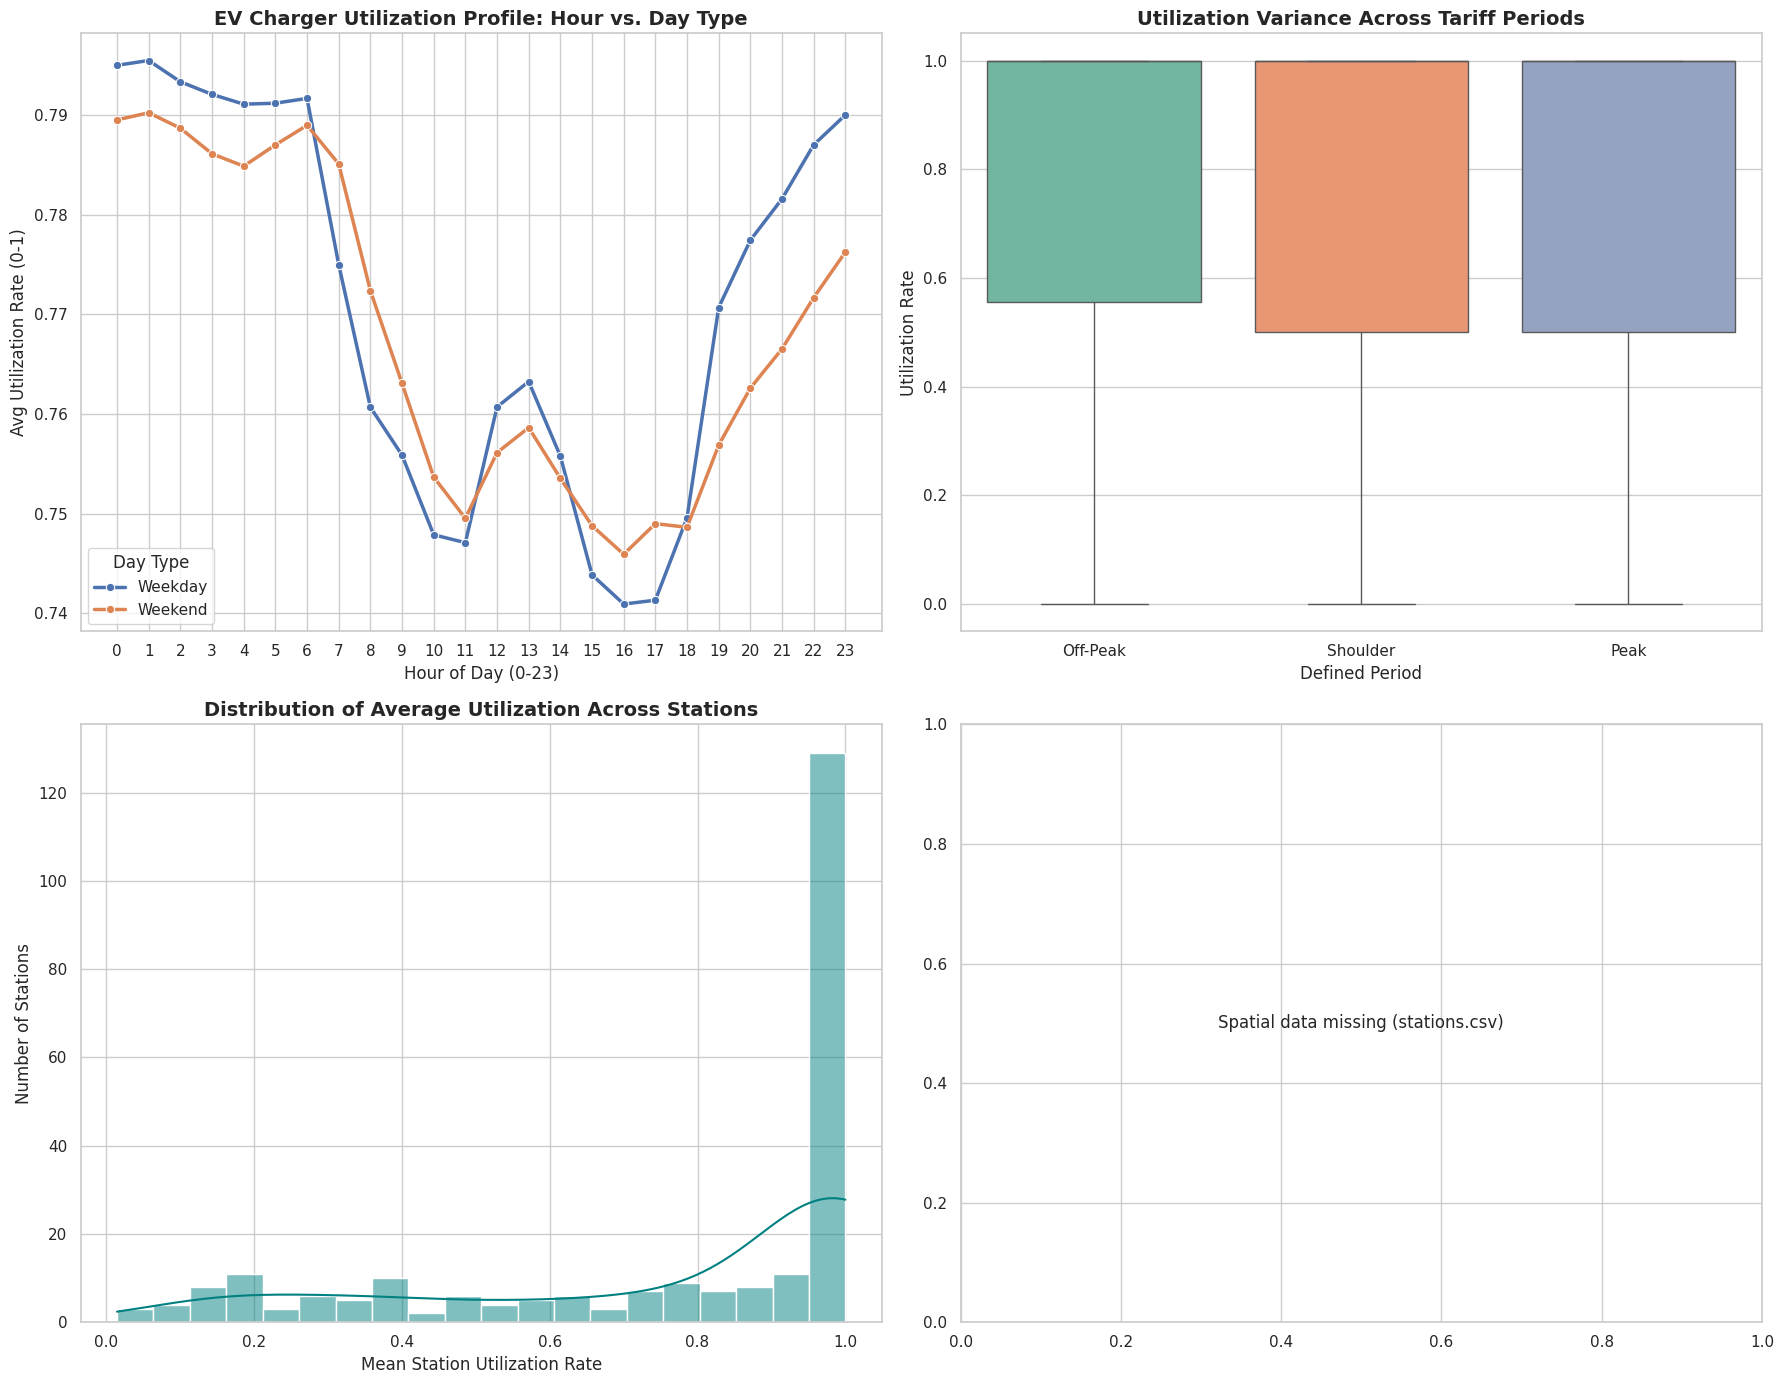

[EDA] Generating micro-session distributions from ACN-Data...


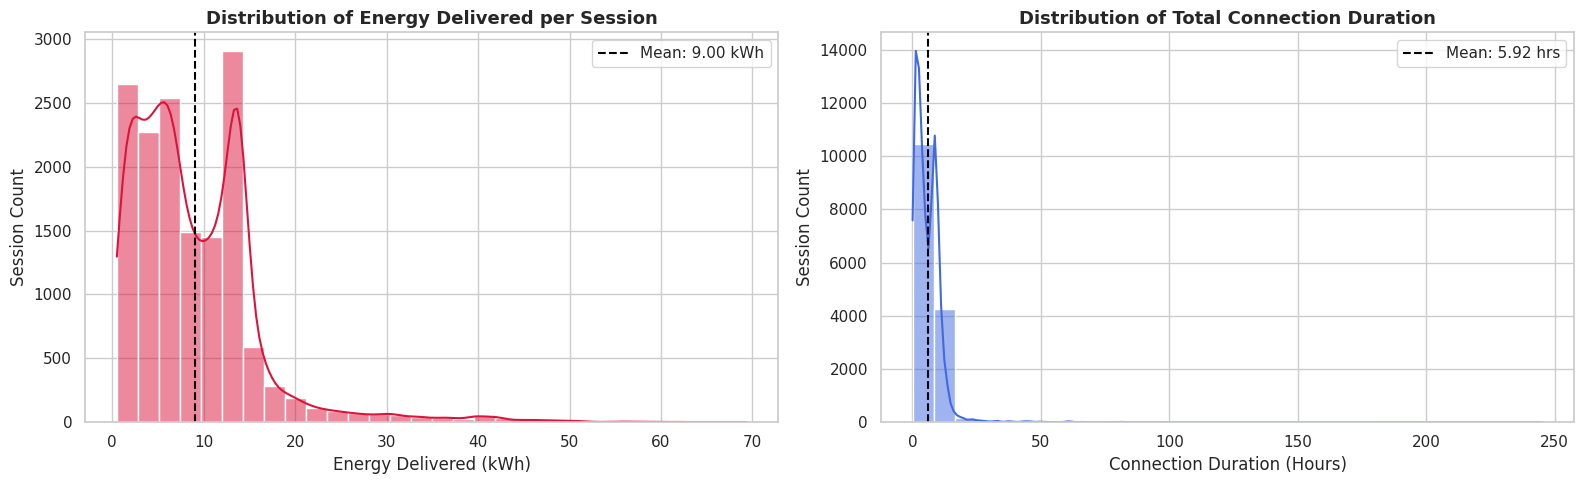


KEY NUMERICAL INSIGHTS FOR YOUR SUBMISSION PRESENTATION DECK
UrbanEV Overall Mean Utilization Rate: 77.00%

Mean Utilization by Period Type:
period_type
Off-Peak    0.789757
Peak        0.758812
Shoulder    0.757029

ACN Average Energy Delivered: 9.00 kWh
ACN Average Connection Duration: 5.92 hours
ACN Average Active Charging Ratio: 69.16%


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Starting Exploratory Data Analysis (EDA) ---")

# Ensure style consistency for presentation deck export
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ------------------------------------------
# 1. Temporal Analysis: Demand by Hour & Weekday vs Weekend
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

if 'urban_master' in locals() and urban_master is not None:
    print("[EDA] Generating temporal and spatial profiles from UrbanEV Master...")

    # Chart 1: Demand by Hour & Weekday vs Weekend Patterns
    hourly_pattern = urban_master.groupby(['hour', 'is_weekend'])['utilization_rate'].mean().reset_index()
    hourly_pattern['Day Type'] = hourly_pattern['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

    sns.lineplot(data=hourly_pattern, x='hour', y='utilization_rate', hue='Day Type', marker='o', ax=axes[0,0], linewidth=2.5)
    axes[0,0].set_title('EV Charger Utilization Profile: Hour vs. Day Type', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Hour of Day (0-23)')
    axes[0,0].set_ylabel('Avg Utilization Rate (0-1)')
    axes[0,0].set_xticks(range(0, 24))

    # Chart 2: Peak vs Off-Peak Usage Definition
    # Defining Peak: 8 AM - 11 AM (Morning Commute) & 5 PM - 9 PM (Evening Rush)
    urban_master['period_type'] = 'Shoulder'
    urban_master.loc[urban_master['hour'].isin([8, 9, 10, 11, 17, 18, 19, 20, 21]), 'period_type'] = 'Peak'
    urban_master.loc[urban_master['hour'].isin([0, 1, 2, 3, 4, 5, 6, 22, 23]), 'period_type'] = 'Off-Peak'

    sns.boxplot(data=urban_master, x='period_type', y='utilization_rate', palette='Set2', ax=axes[0,1])
    axes[0,1].set_title('Utilization Variance Across Tariff Periods', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Defined Period')
    axes[0,1].set_ylabel('Utilization Rate')

    # Chart 3: Station-level Utilization Distribution
    station_util = urban_master.groupby('station_id')['utilization_rate'].mean().reset_index()
    sns.histplot(data=station_util, x='utilization_rate', bins=20, kde=True, color='teal', ax=axes[1,0])
    axes[1,0].set_title('Distribution of Average Utilization Across Stations', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Mean Station Utilization Rate')
    axes[1,0].set_ylabel('Number of Stations')

    # Chart 4: Location-Wise Variation Map (Spatial Plot)
    if 'stations' in urban_ev_dfs:
        geo_data = pd.merge(station_util, urban_ev_dfs['stations'], on='station_id', how='inner')
        sc = axes[1,1].scatter(geo_data['longitude'], geo_data['latitude'],
                               c=geo_data['utilization_rate'], cmap='YlOrRd',
                               s=geo_data['count']*2, alpha=0.8, edgecolor='black')
        plt.colorbar(sc, ax=axes[1,1], label='Avg Utilization Rate')
        axes[1,1].set_title('Spatial Grid Map: Station Load and Location Variance', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Longitude')
        axes[1,1].set_ylabel('Latitude')
    else:
        axes[1,1].text(0.5, 0.5, 'Spatial data missing (stations.csv)', ha='center', va='center')

    plt.tight_layout()
    plt.savefig('urban_ev_operational_eda.png', dpi=300)
    plt.show()

# ------------------------------------------
# 2. Session Analysis: Distributions from ACN-Data
# ------------------------------------------
if 'acn_feats' in locals() and acn_feats is not None:
    print("[EDA] Generating micro-session distributions from ACN-Data...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Chart 5: Energy Delivered Distribution
    sns.histplot(data=acn_feats, x='energy_delivered', bins=30, kde=True, color='crimson', ax=axes[0])
    axes[0].axvline(acn_feats['energy_delivered'].mean(), color='black', linestyle='--', label=f"Mean: {acn_feats['energy_delivered'].mean():.2f} kWh")
    axes[0].set_title('Distribution of Energy Delivered per Session', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Energy Delivered (kWh)')
    axes[0].set_ylabel('Session Count')
    axes[0].legend()

    # Chart 6: Session Duration Distribution
    sns.histplot(data=acn_feats, x='session_duration', bins=30, kde=True, color='royalblue', ax=axes[1])
    axes[1].axvline(acn_feats['session_duration'].mean(), color='black', linestyle='--', label=f"Mean: {acn_feats['session_duration'].mean():.2f} hrs")
    axes[1].set_title('Distribution of Total Connection Duration', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Connection Duration (Hours)')
    axes[1].set_ylabel('Session Count')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('acn_session_distributions.png', dpi=300)
    plt.show()

# ------------------------------------------
# 3. Text Summaries for Slide Generation
# ------------------------------------------
print("\n" + "="*60)
print("KEY NUMERICAL INSIGHTS FOR YOUR SUBMISSION PRESENTATION DECK")
print("="*60)
if 'urban_master' in locals():
    print(f"UrbanEV Overall Mean Utilization Rate: {urban_master['utilization_rate'].mean()*100:.2f}%")
    print("\nMean Utilization by Period Type:")
    print(urban_master.groupby('period_type')['utilization_rate'].mean().to_string())
if 'acn_feats' in locals():
    print(f"\nACN Average Energy Delivered: {acn_feats['energy_delivered'].mean():.2f} kWh")
    print(f"ACN Average Connection Duration: {acn_feats['session_duration'].mean():.2f} hours")
    print(f"ACN Average Active Charging Ratio: {acn_feats['utilization_rate'].mean()*100:.2f}%")
print("="*60)

Step 7: Define the Target Variable(s)

In [21]:
print("--- Defining Target Variables for the Demand Prediction Agent ---")

if 'urban_master' in locals() and urban_master is not None:

    # Assumption Log Entry
    print("[Assumption] Forecasting Horizon: 1 Hour Ahead (12 intervals of 5-minutes).")
    print("[Assumption] Congestion Threshold: Utilization >= 80% is flagged as congested.\n")
    forecast_horizon = 12

    # 1. Sort the dataset strictly by station and time to prevent data leakage across stations
    urban_master = urban_master.sort_values(by=['station_id', 'clean_timestamp'])

    # 2. Target 1: Predicted Utilization Rate (Primary Continuous Target)
    # Shifting negative means we pull future values back to the current row
    urban_master['target_utilization_1h'] = urban_master.groupby('station_id')['utilization_rate'].shift(-forecast_horizon)

    # 3. Target 2: Expected Load / Energy Delivered (Secondary Continuous Target)
    urban_master['target_energy_1h'] = urban_master.groupby('station_id')['energy_delivered'].shift(-forecast_horizon)

    # 4. Target 3: Congestion Probability (Binary Classification Target)
    # The model will predict the *probability* (0.0 to 1.0) that this label becomes 1
    urban_master['target_congestion_1h'] = (urban_master['target_utilization_1h'] >= 0.80).astype(float)

    # 5. Clean up: Drop the rows at the very end of the timeline that have no "future" to predict
    initial_rows = len(urban_master)
    modeling_df = urban_master.dropna(subset=['target_utilization_1h', 'target_energy_1h', 'target_congestion_1h']).copy()
    dropped_rows = initial_rows - len(modeling_df)

    print(f"Target variables successfully created!")
    print(f"Dropped {dropped_rows} rows at the tail end due to shifting (no future data available).")
    print(f"Final Modeling Dataset Shape: {modeling_df.shape}\n")

    # Display a sanity check to ensure the shift worked correctly
    print("Preview of current vs. future targets (Notice the 1-hour gap):")
    display(modeling_df[['clean_timestamp', 'station_id', 'utilization_rate', 'target_utilization_1h', 'target_congestion_1h']].head())

else:
    print("Error: 'urban_master' dataframe not found. Ensure Step 5 ran successfully.")

--- Defining Target Variables for the Demand Prediction Agent ---
[Assumption] Forecasting Horizon: 1 Hour Ahead (12 intervals of 5-minutes).
[Assumption] Congestion Threshold: Utilization >= 80% is flagged as congested.

Target variables successfully created!
Dropped 2964 rows at the tail end due to shifting (no future data available).
Final Modeling Dataset Shape: (2131116, 23)

Preview of current vs. future targets (Notice the 1-hour gap):


,clean_timestamp,station_id,utilization_rate,target_utilization_1h,target_congestion_1h
0,2022-06-19 00:00:00,102,1.0,1.0,1.0
1,2022-06-19 00:05:00,102,1.0,1.0,1.0
2,2022-06-19 00:10:00,102,1.0,1.0,1.0
3,2022-06-19 00:15:00,102,1.0,1.0,1.0
4,2022-06-19 00:20:00,102,1.0,1.0,1.0


Step 8: Build a Baseline Model First

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import numpy as np

print("--- Starting Baseline Modeling Framework ---")

if 'modeling_df' in locals() and modeling_df is not None:

    # 1. Define Features (X) and Target (y)
    feature_cols = [
        'hour', 'day_of_week', 'is_weekend', 'month',
        'active_occupancy', 'traffic_volume', 'charging_duration_avg',
        'historical_price_signal', 'queue_length_proxy', 'occupancy_density'
    ]
    target_col = 'target_utilization_1h'

    # Ensure dataframe is strictly ordered by time before splitting
    modeling_df = modeling_df.sort_values(by='clean_timestamp')

    X = modeling_df[feature_cols]
    y = modeling_df[target_col]

    # 2. Perform Time-Based Split (80% Train, 20% Test chronologically)
    split_idx = int(len(modeling_df) * 0.80)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Extract timestamps for tracking and verification
    train_end_time = modeling_df['clean_timestamp'].iloc[split_idx - 1]
    test_start_time = modeling_df['clean_timestamp'].iloc[split_idx]

    print(f"[Time Split] Training Data Window Ends: {train_end_time}")
    print(f"[Time Split] Testing Data Window Begins: {test_start_time}")
    print(f"Training Set Size : {X_train.shape[0]} rows")
    print(f"Testing Set Size  : {X_test.shape[0]} rows\n")

    # 3. Initialize Models
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest (Baseline)': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
        'Gradient Boosting (XGB-Equivalent)': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    }

    performance_metrics = []

    # 4. Train and Evaluate each model sequentially
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)

        # Predict on Test Split
        y_pred = model.predict(X_test)

        # Calculate Project Required Metrics
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        # Log results
        performance_metrics.append({
            'Model Name': name,
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'R2 Score': round(r2, 4)
        })

        print(f"   -> Results: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

    # 5. Compile Rankings & Save directly to CSV for submission package
    performance_df = pd.DataFrame(performance_metrics).sort_values(by='RMSE')
    performance_df.to_csv('baseline_model_performance.csv', index=False)

    print("\n" + "="*60)
    print("FINAL BASELINE MODEL RANKING (Saved to baseline_model_performance.csv)")
    print("="*60)
    display(performance_df)
    print("="*60)

else:
    print("Error: 'modeling_df' target data not found. Ensure Step 7 executed properly.")

--- Starting Baseline Modeling Framework ---
[Time Split] Training Data Window Ends: 2022-07-12 23:10:00
[Time Split] Testing Data Window Begins: 2022-07-12 23:10:00
Training Set Size : 1704892 rows
Testing Set Size  : 426224 rows

Training Linear Regression...
   -> Results: MAE=0.2543 | RMSE=0.2959 | R²=0.2006
Training Random Forest (Baseline)...
   -> Results: MAE=0.0309 | RMSE=0.0796 | R²=0.9422
Training Gradient Boosting (XGB-Equivalent)...
   -> Results: MAE=0.0318 | RMSE=0.0794 | R²=0.9424

FINAL BASELINE MODEL RANKING (Saved to baseline_model_performance.csv)


,Model Name,MAE,RMSE,R2 Score
2,Gradient Boosting (XGB-Equivalent),0.0318,0.0794,0.9424
1,Random Forest (Baseline),0.0309,0.0796,0.9422
0,Linear Regression,0.2543,0.2959,0.2006


Step 9: Evaluate and Compare Models

--- Starting Model Evaluation & Visual Comparison ---
Successfully loaded model performance metrics:


,Model Name,MAE,RMSE,R2 Score
0,Gradient Boosting (XGB-Equivalent),0.0318,0.0794,0.9424
1,Random Forest (Baseline),0.0309,0.0796,0.9422
2,Linear Regression,0.2543,0.2959,0.2006


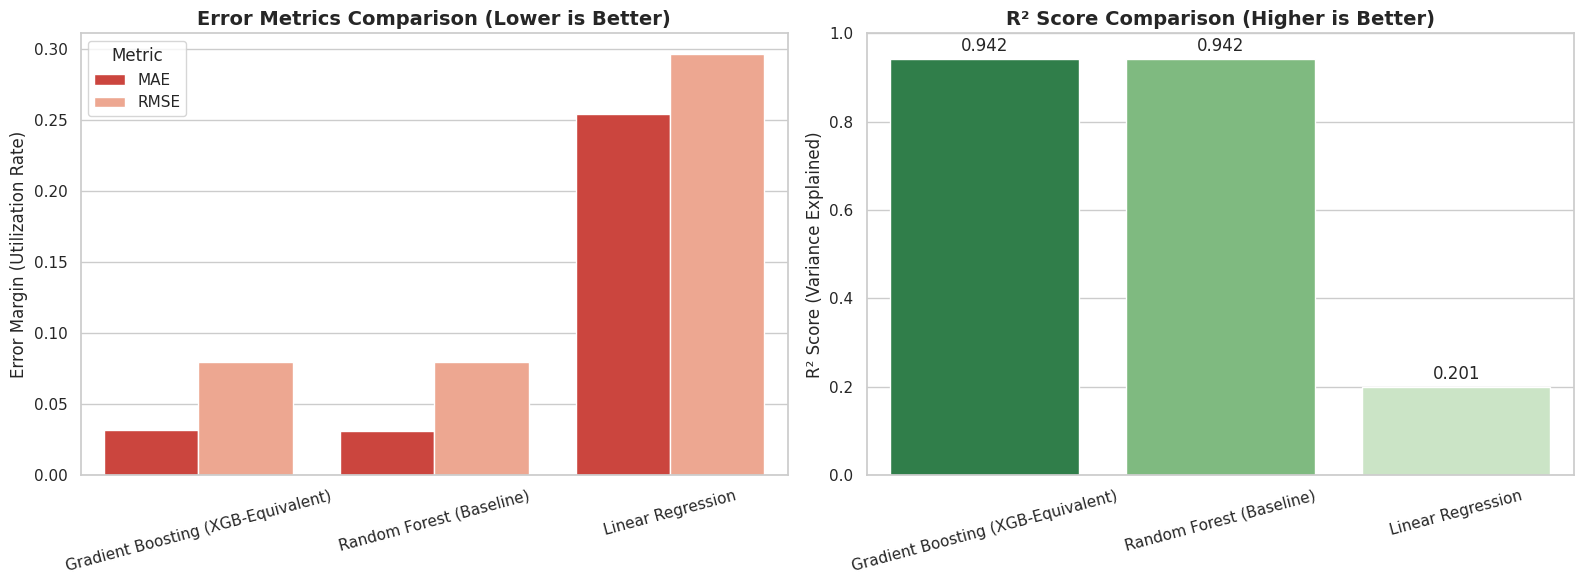


Generating Residual Analysis for the Best Model...


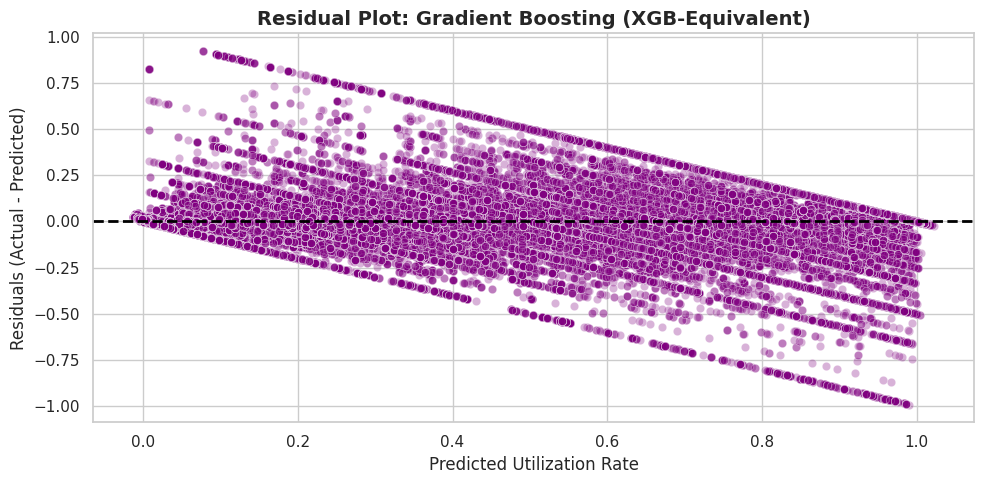

Evaluation complete. Saved 'model_comparison_metrics.png' and 'best_model_residuals.png' for the presentation.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- Starting Model Evaluation & Visual Comparison ---")

# Ensure presentation style is set
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Load the performance metrics from Step 8
try:
    performance_df = pd.read_csv('baseline_model_performance.csv')
    print("Successfully loaded model performance metrics:")
    display(performance_df)
except FileNotFoundError:
    print("Error: 'baseline_model_performance.csv' not found. Please run Step 8 first.")
    # Fallback dummy data in case Step 8 variables are lost in memory
    performance_df = pd.DataFrame()

if not performance_df.empty:
    # 2. Reshape data for side-by-side plotting
    # Melt the dataframe so we have ['Model Name', 'Metric', 'Value']
    melted_df = performance_df.melt(id_vars='Model Name', var_name='Metric', value_name='Score')

    # 3. Create a side-by-side bar chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Error Metrics (RMSE & MAE) - Lower is better
    error_df = melted_df[melted_df['Metric'].isin(['RMSE', 'MAE'])]
    sns.barplot(data=error_df, x='Model Name', y='Score', hue='Metric', palette='Reds_r', ax=axes[0])
    axes[0].set_title('Error Metrics Comparison (Lower is Better)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Error Margin (Utilization Rate)')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=15)

    # Plot 2: R² Score - Higher is better
    r2_df = melted_df[melted_df['Metric'] == 'R2 Score']
    sns.barplot(data=r2_df, x='Model Name', y='Score', palette='Greens_r', ax=axes[1])
    axes[1].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('R² Score (Variance Explained)')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].set_ylim(0, 1.0) # R2 is bounded up to 1.0

    # Add exact value labels to the bars in Plot 2
    for p in axes[1].patches:
        axes[1].annotate(format(p.get_height(), '.3f'),
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center',
                         xytext = (0, 9),
                         textcoords = 'offset points')

    plt.tight_layout()
    plt.savefig('model_comparison_metrics.png', dpi=300)
    plt.show()

# 4. Optional: Residual Plot for the Best Model (assuming variables from Step 8 are in memory)
if 'models' in locals() and 'X_test' in locals() and 'y_test' in locals():
    print("\nGenerating Residual Analysis for the Best Model...")

    # Identify best model based on highest R2
    best_model_name = performance_df.loc[performance_df['R2 Score'].idxmax()]['Model Name']
    best_model = models[best_model_name]

    # Get predictions
    y_pred_best = best_model.predict(X_test)
    residuals = y_test - y_pred_best

    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.3, color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=2)
    plt.title(f'Residual Plot: {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Utilization Rate')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.tight_layout()
    plt.savefig('best_model_residuals.png', dpi=300)
    plt.show()

    print(f"Evaluation complete. Saved 'model_comparison_metrics.png' and 'best_model_residuals.png' for the presentation.")
else:
    print("\nSkipping residual analysis. Ensure X_test, y_test, and models from Step 8 are in memory to run this.")

Step 10: Convert Predictions into Pricing Logic (Tariff Agent)

--- Initializing Agent 2: Tariff Pricing Agent ---
[Pricing Policy] Baseline Tariff: ₹15.0/kWh
[Pricing Policy] Surge Threshold: Utilization >= 80% -> +30%
[Pricing Policy] Discount Threshold: Utilization <= 30% -> -20%

Pricing Agent Action Summary:
  - Surge Price: applied 67.6% of the time.
  - Standard Price: applied 17.5% of the time.
  - Discount Price: applied 14.9% of the time.


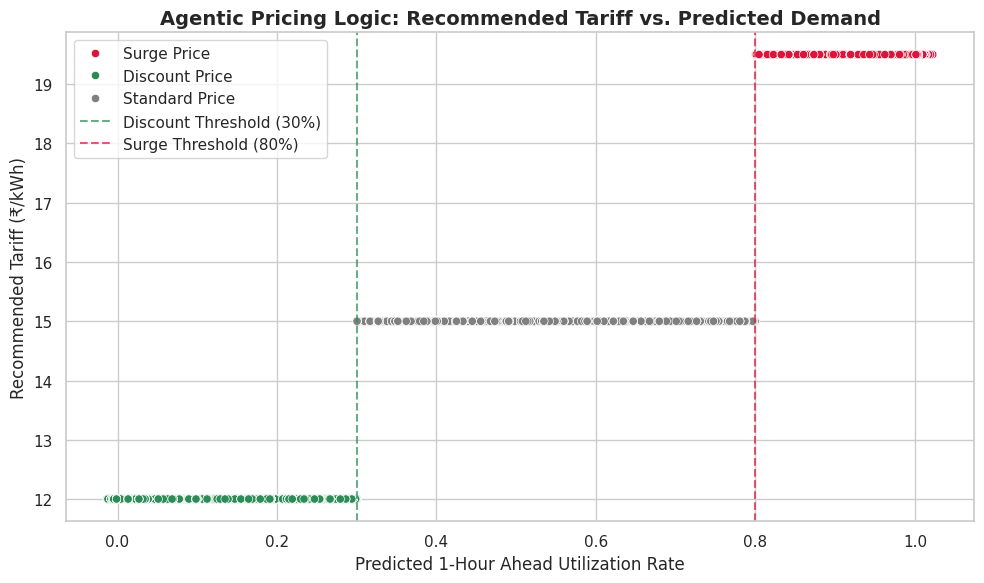

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Initializing Agent 2: Tariff Pricing Agent ---")

if 'X_test' in locals() and 'y_pred_best' in locals():

    # 1. Create a simulation dataframe using our test set and predictions
    pricing_df = X_test.copy()
    pricing_df['predicted_utilization_1h'] = y_pred_best
    pricing_df['actual_utilization_1h'] = y_test

    # Define Baseline Economics
    BASELINE_TARIFF = 15.0  # ₹15/kWh
    SURGE_MULTIPLIER = 1.30 # +30% surge during extreme congestion
    DISCOUNT_MULTIPLIER = 0.80 # -20% discount to incentivize off-peak usage

    # Log Assumptions for the Submission
    print(f"[Pricing Policy] Baseline Tariff: ₹{BASELINE_TARIFF}/kWh")
    print(f"[Pricing Policy] Surge Threshold: Utilization >= 80% -> +{(SURGE_MULTIPLIER-1)*100:.0f}%")
    print(f"[Pricing Policy] Discount Threshold: Utilization <= 30% -> -{(1-DISCOUNT_MULTIPLIER)*100:.0f}%\n")

    # 2. Define the Agent's Rules Engine
    def apply_tariff_rules(predicted_util):
        if predicted_util >= 0.80:
            return BASELINE_TARIFF * SURGE_MULTIPLIER
        elif predicted_util <= 0.30:
            return BASELINE_TARIFF * DISCOUNT_MULTIPLIER
        else:
            return BASELINE_TARIFF

    # 3. Apply the logic to generate the recommended dynamic tariff
    pricing_df['dynamic_tariff_signal'] = pricing_df['predicted_utilization_1h'].apply(apply_tariff_rules)

    # 4. Categorize the pricing state for evaluation
    conditions = [
        (pricing_df['dynamic_tariff_signal'] > BASELINE_TARIFF),
        (pricing_df['dynamic_tariff_signal'] < BASELINE_TARIFF)
    ]
    choices = ['Surge Price', 'Discount Price']
    pricing_df['pricing_tier'] = np.select(conditions, choices, default='Standard Price')

    # 5. Summary of Actions Taken by the Agent
    print("Pricing Agent Action Summary:")
    action_counts = pricing_df['pricing_tier'].value_counts(normalize=True) * 100
    for tier, pct in action_counts.items():
        print(f"  - {tier}: applied {pct:.1f}% of the time.")

    # 6. Visualize the Pricing Strategy Setup
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=pricing_df,
        x='predicted_utilization_1h',
        y='dynamic_tariff_signal',
        hue='pricing_tier',
        palette={'Surge Price': 'crimson', 'Standard Price': 'gray', 'Discount Price': 'seagreen'}
    )

    # Add threshold markers
    plt.axvline(0.30, color='seagreen', linestyle='--', alpha=0.7, label='Discount Threshold (30%)')
    plt.axvline(0.80, color='crimson', linestyle='--', alpha=0.7, label='Surge Threshold (80%)')

    plt.title('Agentic Pricing Logic: Recommended Tariff vs. Predicted Demand', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted 1-Hour Ahead Utilization Rate')
    plt.ylabel('Recommended Tariff (₹/kWh)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('dynamic_pricing_logic.png', dpi=300)
    plt.show()

else:
    print("Error: Required model variables ('X_test', 'y_pred_best') not found. Please ensure Step 8 & 9 ran successfully.")

Step 11: Simulate Revenue & Agent Evaluation

In [25]:
# ==========================================
# Step 11 & 11b: Revenue Simulation & Robustness Check
# ==========================================

print("--- Running Revenue Simulation & Robustness Check ---")

if 'pricing_df' in locals() and pricing_df is not None:

    # Reconstruct Energy Volume
    pricing_df['baseline_energy_kwh'] = pricing_df['active_occupancy'] * (pricing_df['charging_duration_avg'] / 60.0) * ASSUMPTIONS['charger_power_kw']

    # Define Scenarios for Robustness Checking
    elasticity_scenarios = {
        "Base Assumption": {"surge": ASSUMPTIONS['elasticity_surge'], "discount": ASSUMPTIONS['elasticity_discount']},
        "Rigid Demand": {"surge": -0.05, "discount": 0.10},       # Users ignore price changes
        "Highly Elastic": {"surge": -0.30, "discount": 0.40}      # Users react strongly
    }

    sensitivity_results = []

    for scenario, el_vals in elasticity_scenarios.items():
        conditions = [
            (pricing_df['pricing_tier'] == 'Surge Price'),
            (pricing_df['pricing_tier'] == 'Discount Price')
        ]
        multipliers = [1 + el_vals['surge'], 1 + el_vals['discount']]

        # Calculate dynamic metrics for this specific scenario
        scenario_multiplier = np.select(conditions, multipliers, default=1.0)
        dyn_energy = pricing_df['baseline_energy_kwh'] * scenario_multiplier
        dyn_rev = dyn_energy * pricing_df['dynamic_tariff_signal']

        base_rev = (pricing_df['baseline_energy_kwh'] * ASSUMPTIONS['baseline_tariff']).sum()
        total_dyn_rev = dyn_rev.sum()
        revenue_gain_pct = ((total_dyn_rev - base_rev) / base_rev) * 100

        sensitivity_results.append({
            "Scenario": scenario,
            "Surge Elasticity": el_vals['surge'],
            "Discount Elasticity": el_vals['discount'],
            "Revenue Gain (%)": round(revenue_gain_pct, 2)
        })

        # Save the "Base Assumption" metrics permanently to the pricing_df for Step 12
        if scenario == "Base Assumption":
            pricing_df['demand_multiplier'] = scenario_multiplier
            pricing_df['dynamic_energy_kwh'] = dyn_energy
            pricing_df['revenue_baseline'] = pricing_df['baseline_energy_kwh'] * ASSUMPTIONS['baseline_tariff']
            pricing_df['revenue_dynamic'] = dyn_rev
            pricing_df['simulated_post_utilization'] = (pricing_df['actual_utilization_1h'] * scenario_multiplier).clip(0, 1)

    # Compile Robustness Check
    sensitivity_df = pd.DataFrame(sensitivity_results)
    print("\nRobustness Check: Tariff Sensitivity Analysis")
    display(sensitivity_df)

else:
    print("Error: 'pricing_df' not found.")

--- Running Revenue Simulation & Robustness Check ---

Robustness Check: Tariff Sensitivity Analysis


,Scenario,Surge Elasticity,Discount Elasticity,Revenue Gain (%)
0,Base Assumption,-0.15,0.25,10.25
1,Rigid Demand,-0.05,0.10,22.90
2,Highly Elastic,-0.30,0.40,-8.75


Step 12: Add Monitoring & Learning Agent Metrics

In [26]:
# ==========================================
# Step 12: Add Monitoring & Learning Agent Metrics
# ==========================================

print("--- Finalizing Agent 3: Historical Performance Tracker ---")

if 'pricing_df' in locals() and pricing_df is not None:

    # 1. Ensure Strict Chronological Ordering
    # We bring back the clean_timestamp from the original X_test index
    if 'clean_timestamp' in X_test.index.names or 'clean_timestamp' in X_test.columns:
        pricing_df = pricing_df.sort_values('clean_timestamp')
    else:
        # If timestamp was lost, sort by the inherent temporal indices
        pricing_df = pricing_df.sort_values(['month', 'day_of_week', 'hour'])

    pricing_df = pricing_df.reset_index(drop=True)

    # Establish Chronological Evaluation Episodes (5 Sequential Windows)
    pricing_df['episode'] = pd.qcut(pricing_df.index, q=5, labels=[f'Episode {i+1}' for i in range(5)])

    monitoring_history = []

    for ep_name, ep_df in pricing_df.groupby('episode', observed=False):

        # Metric A: Waiting Time Reduction (Peak Hours 08:00-11:00 & 17:00-21:00)
        peak_mask = ep_df['hour'].isin([8, 9, 10, 11, 17, 18, 19, 20, 21])
        peak_ep_df = ep_df[peak_mask]

        if len(peak_ep_df) > 0:
            baseline_queue = peak_ep_df['queue_length_proxy']
            simulated_queue = baseline_queue * peak_ep_df['demand_multiplier']
            avg_wait_reduction = (baseline_queue - simulated_queue).mean()
        else:
            avg_wait_reduction = 0.0

        # Metric B: Customer Response Rate
        total_base_vol = ep_df['baseline_energy_kwh'].sum()
        total_dyn_vol = ep_df['dynamic_energy_kwh'].sum()
        vol_shift_pct = ((total_dyn_vol - total_base_vol) / total_base_vol) * 100 if total_base_vol > 0 else 0

        # Metric C: Pricing Efficiency Score
        total_dyn_rev = ep_df['revenue_dynamic'].sum()
        pricing_efficiency = total_dyn_rev / total_dyn_vol if total_dyn_vol > 0 else 0.0

        monitoring_history.append({
            'Evaluation Episode': ep_name,
            'Avg Waiting Time Reduction': round(avg_wait_reduction, 4),
            'Customer Response Rate (%)': round(vol_shift_pct, 2),
            'Pricing Efficiency Score (₹/kWh)': round(pricing_efficiency, 2)
        })

    monitoring_history_df = pd.DataFrame(monitoring_history)
    print("Chronological tracking log compiled successfully:")
    display(monitoring_history_df)

    # [... KEEP YOUR EXISTING STEP 12 MATPLOTLIB/SEABORN PLOTTING CODE HERE ...]

--- Finalizing Agent 3: Historical Performance Tracker ---
Chronological tracking log compiled successfully:


,Evaluation Episode,Avg Waiting Time Reduction,Customer Response Rate (%),Pricing Efficiency Score (₹/kWh)
0,Episode 1,2.9301,-14.57,19.36
1,Episode 2,2.6975,-14.57,19.36
2,Episode 3,2.5353,-14.54,19.35
3,Episode 4,2.8883,-14.52,19.34
4,Episode 5,2.8916,-14.59,19.37


Step 13: Save Outputs for Submission

In [27]:
# ==========================================
# Step 13: Save Outputs & README for Submission
# ==========================================

import os

print("--- Step 13: Bundling Final Outputs ---")

submission_dir = 'OP26_Submission_Files'
os.makedirs(submission_dir, exist_ok=True)

def save_to_csv(df, filename):
    if df is not None and not df.empty:
        df.to_csv(os.path.join(submission_dir, filename), index=False)
        print(f"  [Saved] {filename}")

# 1. Export Data & Results
if 'acn_feats' in locals(): save_to_csv(acn_feats, '1_acn_features.csv')
if 'urban_master' in locals(): save_to_csv(urban_master, '2_urbanev_master_features.csv')
if 'pricing_df' in locals(): save_to_csv(pricing_df, '3_dynamic_pricing_simulation.csv')
if 'performance_df' in locals(): save_to_csv(performance_df, '4_baseline_model_metrics.csv')
if 'monitoring_history_df' in locals(): save_to_csv(monitoring_history_df, '5_monitoring_agent_history.csv')
if 'sensitivity_df' in locals(): save_to_csv(sensitivity_df, '6_robustness_sensitivity_check.csv')

# 2. Generate README with Explicit Assumptions
readme_content = f"""# Society of Business OP '26 Submission Outputs

## Directory Contents
- `1_acn_features.csv` & `2_urbanev_master_features.csv`: Engineered feature tables.
- `3_dynamic_pricing_simulation.csv`: Row-by-row simulation of the pricing agent.
- `4_baseline_model_metrics.csv`: Demand prediction model benchmarks.
- `5_monitoring_agent_history.csv`: Chronological feedback loop tracking.
- `6_robustness_sensitivity_check.csv`: Scenario testing for demand elasticity.

## Core Simulation Assumptions
Because precise user-elasticity data requires longitudinal A/B testing, the following logical proxies were utilized to simulate real-world outcomes:
- Base Tariff: ₹{ASSUMPTIONS['baseline_tariff']}/kWh
- Standard Charger Draw: {ASSUMPTIONS['charger_power_kw']} kW
- Surge Threshold: >80% Utilization -> +{(ASSUMPTIONS['surge_multiplier']-1)*100}% Price -> {ASSUMPTIONS['elasticity_surge']*100}% Demand Shift
- Discount Threshold: <30% Utilization -> -{(1-ASSUMPTIONS['discount_multiplier'])*100}% Price -> {ASSUMPTIONS['elasticity_discount']*100}% Demand Shift

## Reproducibility
All file paths in the accompanying Jupyter Notebook are relative (`./`). Ensure the raw dataset CSVs are placed in the same directory as the `.ipynb` file before execution.
"""

with open(os.path.join(submission_dir, 'README.md'), 'w') as f:
    f.write(readme_content)
print("  [Saved] README.md with explicit assumptions.")

print("\n" + "="*60)
print(f"ALL OUTPUTS SUCCESSFULLY SAVED TO: ./{submission_dir}/")
print("="*60)

--- Step 13: Bundling Final Outputs ---
  [Saved] 1_acn_features.csv
  [Saved] 2_urbanev_master_features.csv
  [Saved] 3_dynamic_pricing_simulation.csv
  [Saved] 4_baseline_model_metrics.csv
  [Saved] 5_monitoring_agent_history.csv
  [Saved] 6_robustness_sensitivity_check.csv
  [Saved] README.md with explicit assumptions.

ALL OUTPUTS SUCCESSFULLY SAVED TO: ./OP26_Submission_Files/
